# Two-Way ANOVA on Loan Amounts

This project investigates whether loan amounts differ based on:

- Education level (`person_education`)
- Home ownership status (`person_home_ownership`)

A two-way ANOVA is used to evaluate:
- Main effects of each variable
- Interaction between the two variables

The analysis also includes assumption checks, post-hoc testing, and visualizations.

## Imports and Setup

This section imports all required libraries for:
- Data handling (`pandas`)
- Statistical testing (`scipy`, `statsmodels`)
- Visualization (`matplotlib`)

Warnings related to runtime issues are suppressed for cleaner output.

In [1]:
from pathlib import Path
import warnings

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import shapiro, levene
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

warnings.filterwarnings("ignore", category=RuntimeWarning)

## Load and Prepare Data

The dataset is loaded from a local file path.

Steps performed:
- Verify file existence
- Load data into a DataFrame
- Select relevant variables:
  - `person_education`
  - `person_home_ownership`
  - `loan_amount`
- Drop missing values
- Convert categorical variables to appropriate data types

This ensures the dataset is ready for statistical analysis.

In [2]:
file_path = Path(r"C:\Users\steve\Documents\Datasets\Raw\Loan Approval Classification\loan_data.csv")

if not file_path.exists():
    raise FileNotFoundError(f"File not found: {file_path}")

df = pd.read_csv(file_path)

# Variables for analysis
factor_a = "person_education"
factor_b = "person_home_ownership"
dv = "loan_amount"

required_cols = [factor_a, factor_b, dv]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in dataset: {missing}")

data = df[required_cols].copy().dropna()

data[factor_a] = data[factor_a].astype("category")
data[factor_b] = data[factor_b].astype("category")

## Data Overview

This section provides an initial inspection of the dataset:
- Displays the first few rows
- Reports dataset shape after cleaning
- Lists category levels for each factor

This helps confirm that the data has been loaded and structured correctly.

In [3]:
print("\n" + "=" * 70)
print("DATA OVERVIEW")
print("=" * 70)
print(data.head())
print(f"\nShape after dropping missing values: {data.shape}")

print("\nLevels in person_education:")
print(list(data[factor_a].cat.categories))

print("\nLevels in person_home_ownership:")
print(list(data[factor_b].cat.categories))


DATA OVERVIEW
  person_education person_home_ownership  loan_amount
0           Master                  RENT        35000
1      High School                   OWN         1000
2      High School              MORTGAGE         5500
3         Bachelor                  RENT        35000
4           Master                  RENT        35000

Shape after dropping missing values: (45000, 3)

Levels in person_education:
['Associate', 'Bachelor', 'Doctorate', 'High School', 'Master']

Levels in person_home_ownership:
['MORTGAGE', 'OTHER', 'OWN', 'RENT']


## Group Counts and Summary Statistics

This section examines the structure of the data across groups:

- Counts observations for each combination of:
  - Education level
  - Home ownership status

- Computes summary statistics for each group:
  - Mean loan amount
  - Standard deviation
  - Sample size

Main effect means are also calculated separately for each factor.

These summaries help identify:
- Imbalanced group sizes
- Potential anomalies (e.g., very small groups)

In [4]:
print("\n" + "=" * 70)
print("GROUP COUNTS")
print("=" * 70)

group_counts = (
    data.groupby([factor_a, factor_b], observed=False)
    .size()
    .reset_index(name="count")
)
print(group_counts)

print("\n" + "=" * 70)
print("GROUP SUMMARY: MEAN / SD / N")
print("=" * 70)

group_summary = (
    data.groupby([factor_a, factor_b], observed=False)[dv]
    .agg(mean="mean", std="std", count="size")
    .reset_index()
)
print(group_summary)

print("\n" + "=" * 70)
print("MAIN EFFECT MEANS")
print("=" * 70)

means_a = data.groupby(factor_a, observed=False)[dv].mean().sort_values(ascending=False)
means_b = data.groupby(factor_b, observed=False)[dv].mean().sort_values(ascending=False)

print(f"\nMean {dv} by {factor_a}:")
print(means_a)

print(f"\nMean {dv} by {factor_b}:")
print(means_b)


GROUP COUNTS
   person_education person_home_ownership  count
0         Associate              MORTGAGE   4969
1         Associate                 OTHER     35
2         Associate                   OWN    804
3         Associate                  RENT   6220
4          Bachelor              MORTGAGE   5442
5          Bachelor                 OTHER     41
6          Bachelor                   OWN    854
7          Bachelor                  RENT   7062
8         Doctorate              MORTGAGE    280
9         Doctorate                 OTHER      1
10        Doctorate                   OWN     44
11        Doctorate                  RENT    296
12      High School              MORTGAGE   4933
13      High School                 OTHER     29
14      High School                   OWN    756
15      High School                  RENT   6254
16           Master              MORTGAGE   2865
17           Master                 OTHER     11
18           Master                   OWN    493
19    

## Two-Way ANOVA Model

A two-way ANOVA model is fitted using the formula:

loan_amount ~ person_education * person_home_ownership

This model evaluates:
- Main effect of education
- Main effect of home ownership
- Interaction effect between the two variables

Type II sum of squares is used.

Effect size (η²) is also calculated to assess the magnitude of each effect.

In [5]:
formula = f"{dv} ~ C({factor_a}) * C({factor_b})"
model = smf.ols(formula, data=data).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

# Add eta-squared
anova_table["eta_sq"] = anova_table["sum_sq"] / anova_table["sum_sq"].sum()

print("\n" + "=" * 70)
print("TWO-WAY ANOVA RESULTS (TYPE II)")
print("=" * 70)
print(anova_table)


TWO-WAY ANOVA RESULTS (TYPE II)
                                                    sum_sq       df  \
C(person_education)                           9.030180e+07      4.0   
C(person_home_ownership)                      4.115570e+10      3.0   
C(person_education):C(person_home_ownership)  5.058238e+08     12.0   
Residual                                      1.752670e+12  44980.0   

                                                       F         PR(>F)  \
C(person_education)                             0.579369   6.775903e-01   
C(person_home_ownership)                      352.069144  5.105432e-226   
C(person_education):C(person_home_ownership)    1.081776   3.704321e-01   
Residual                                             NaN            NaN   

                                                eta_sq  
C(person_education)                           0.000050  
C(person_home_ownership)                      0.022935  
C(person_education):C(person_home_ownership)  0.000282  
Residua

## Assumption Checks

The validity of ANOVA depends on several assumptions:

### 1. Normality of Residuals
- Tested using the Shapiro-Wilk test

### 2. Homogeneity of Variance
- Tested using Levene’s test across groups

These checks help determine whether the ANOVA results can be reliably interpreted.

In [6]:
print("\n" + "=" * 70)
print("ASSUMPTION CHECKS")
print("=" * 70)

# 4a) Normality of residuals
residuals = model.resid
sample_for_shapiro = residuals.sample(min(len(residuals), 5000), random_state=42)
shapiro_stat, shapiro_p = shapiro(sample_for_shapiro)

print(f"\nShapiro-Wilk test on residuals: statistic = {shapiro_stat:.4f}, p = {shapiro_p:.4f}")
if shapiro_p < 0.05:
    print("Interpretation: residuals may deviate from normality.")
else:
    print("Interpretation: no strong evidence against normality of residuals.")

# 4b) Homogeneity of variances across cells
cell_groups = [
    grp[dv].values
    for _, grp in data.groupby([factor_a, factor_b], observed=False)
    if len(grp) > 1
]

if len(cell_groups) >= 2:
    lev_stat, lev_p = levene(*cell_groups)
    print(f"\nLevene's test: statistic = {lev_stat:.4f}, p = {lev_p:.4f}")
    if lev_p < 0.05:
        print("Interpretation: group variances may not be equal.")
    else:
        print("Interpretation: no strong evidence against equal variances.")
else:
    print("\nLevene's test could not be performed because there were not enough groups with 2+ observations.")



ASSUMPTION CHECKS

Shapiro-Wilk test on residuals: statistic = 0.9139, p = 0.0000
Interpretation: residuals may deviate from normality.

Levene's test: statistic = 27.6209, p = 0.0000
Interpretation: group variances may not be equal.


## Model Summary

The full OLS regression summary is displayed, including:
- Coefficients
- R-squared
- F-statistics
- Diagnostic information

This provides a detailed statistical view of the fitted model.

In [7]:
print("\n" + "=" * 70)
print("OLS MODEL SUMMARY")
print("=" * 70)
print(model.summary())


OLS MODEL SUMMARY
                            OLS Regression Results                            
Dep. Variable:            loan_amount   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     56.45
Date:                Wed, 01 Apr 2026   Prob (F-statistic):          7.70e-213
Time:                        12:32:31   Log-Likelihood:            -4.5710e+05
No. Observations:               45000   AIC:                         9.142e+05
Df Residuals:                   44980   BIC:                         9.144e+05
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                                                           coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

## Significance Testing

This section extracts p-values from the ANOVA table to determine:

- Whether each main effect is statistically significant
- Whether the interaction effect is significant

Results are compared against α = 0.05 and clearly labeled as:
- Significant
- Not significant

In [8]:
alpha = 0.05

p_a = anova_table.loc[f"C({factor_a})", "PR(>F)"] if f"C({factor_a})" in anova_table.index else None
p_b = anova_table.loc[f"C({factor_b})", "PR(>F)"] if f"C({factor_b})" in anova_table.index else None
p_interaction = (
    anova_table.loc[f"C({factor_a}):C({factor_b})", "PR(>F)"]
    if f"C({factor_a}):C({factor_b})" in anova_table.index
    else None
)

sig_a = p_a is not None and p_a < alpha
sig_b = p_b is not None and p_b < alpha
sig_interaction = p_interaction is not None and p_interaction < alpha


print("\n" + "=" * 70)
print("SIGNIFICANCE SUMMARY")
print("=" * 70)

if p_a is not None:
    print(f"{factor_a}: p = {p_a:.4f} -> {'SIGNIFICANT' if sig_a else 'not significant'}")

if p_b is not None:
    print(f"{factor_b}: p = {p_b:.4f} -> {'SIGNIFICANT' if sig_b else 'not significant'}")

if p_interaction is not None:
    print(f"{factor_a} x {factor_b}: p = {p_interaction:.4f} -> {'SIGNIFICANT' if sig_interaction else 'not significant'}")



SIGNIFICANCE SUMMARY
person_education: p = 0.6776 -> not significant
person_home_ownership: p = 0.0000 -> SIGNIFICANT
person_education x person_home_ownership: p = 0.3704 -> not significant


## Post-hoc Analysis (Tukey HSD)

Post-hoc tests are performed only for factors with significant main effects.

Tukey’s Honest Significant Difference (HSD) test is used to:
- Compare all pairwise group differences
- Identify which specific groups differ significantly

No post-hoc tests are performed for non-significant factors.

In [9]:
print("\n" + "=" * 70)
print("POST-HOC TESTS (ONLY FOR SIGNIFICANT MAIN EFFECTS)")
print("=" * 70)

if sig_a:
    print(f"\nTukey HSD for {factor_a}")
    tukey_a = pairwise_tukeyhsd(endog=data[dv], groups=data[factor_a], alpha=alpha)
    print(tukey_a.summary())
else:
    print(f"\n{factor_a} is not significant. No Tukey test run for this factor.")

if sig_b:
    print(f"\nTukey HSD for {factor_b}")
    tukey_b = pairwise_tukeyhsd(endog=data[dv], groups=data[factor_b], alpha=alpha)
    print(tukey_b.summary())
else:
    print(f"\n{factor_b} is not significant. No Tukey test run for this factor.")



POST-HOC TESTS (ONLY FOR SIGNIFICANT MAIN EFFECTS)

person_education is not significant. No Tukey test run for this factor.

Tukey HSD for person_home_ownership
     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
 group1  group2  meandiff  p-adj    lower      upper    reject
--------------------------------------------------------------
MORTGAGE  OTHER   565.4926 0.7627  -921.8109   2052.796  False
MORTGAGE    OWN  -1736.512    0.0 -2054.4144 -1418.6096   True
MORTGAGE   RENT -1960.3752    0.0 -2118.1117 -1802.6387   True
   OTHER    OWN -2302.0046 0.0005 -3813.7298  -790.2793   True
   OTHER   RENT -2525.8678 0.0001 -4012.1827 -1039.5529   True
     OWN   RENT  -223.8632 0.2564  -537.1082    89.3818  False
--------------------------------------------------------------


## Inspecting Potential Anomalies

This section examines group-level statistics in more detail, including:
- Mean
- Count
- Standard deviation
- Minimum and maximum values

This helps identify:
- Outliers
- Groups with very small sample sizes

For example, a spike observed in the interaction plot may be due to a group with very few observations rather than a true effect.

In [10]:
print("\n" + "=" * 70)
print("INSPECTING CELL COUNTS AND MEANS FOR POSSIBLE SPIKES")
print("=" * 70)

cell_summary = (
    data.groupby([factor_a, factor_b], observed=False)[dv]
    .agg(mean="mean", count="size", std="std", min="min", max="max")
    .reset_index()
)
print(cell_summary)


INSPECTING CELL COUNTS AND MEANS FOR POSSIBLE SPIKES
   person_education person_home_ownership          mean  count          std  \
0         Associate              MORTGAGE  10797.699738   4969  6902.034104   
1         Associate                 OTHER  10747.342857     35  6283.711440   
2         Associate                   OWN   9039.829602    804  6288.801997   
3         Associate                  RENT   8763.263826   6220  5699.766012   
4          Bachelor              MORTGAGE  10569.873943   5442  6770.577213   
5          Bachelor                 OTHER  11590.853659     41  6005.148198   
6          Bachelor                   OWN   9023.180328    854  6183.280566   
7          Bachelor                  RENT   8827.539507   7062  5801.193120   
8         Doctorate              MORTGAGE  11482.035714    280  7110.399728   
9         Doctorate                 OTHER  20000.000000      1          NaN   
10        Doctorate                   OWN   9752.772727     44  6700.783702  

## Visualizations

Several plots are created to support interpretation:

### Interaction Plot
- Shows how mean loan amounts vary across combinations of the two factors
- Used to visually assess interaction effects

### Boxplot
- Displays the distribution of loan amounts across groups
- Highlights spread, medians, and potential outliers

### Main Effect Plots
- Show mean loan amounts for each factor separately
- Include approximate 95% confidence intervals

These visualizations complement the statistical results and help identify patterns or anomalies.

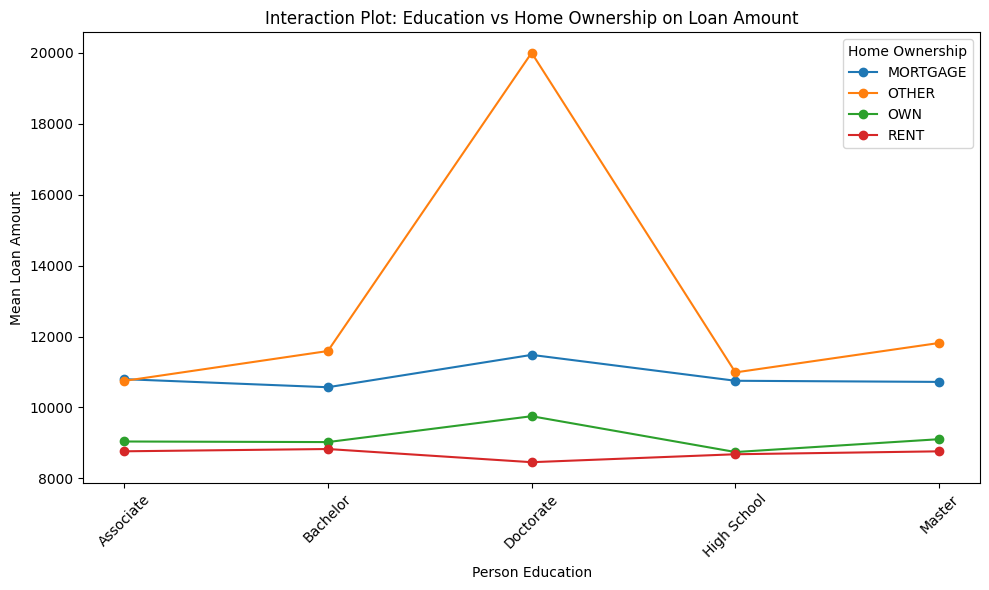

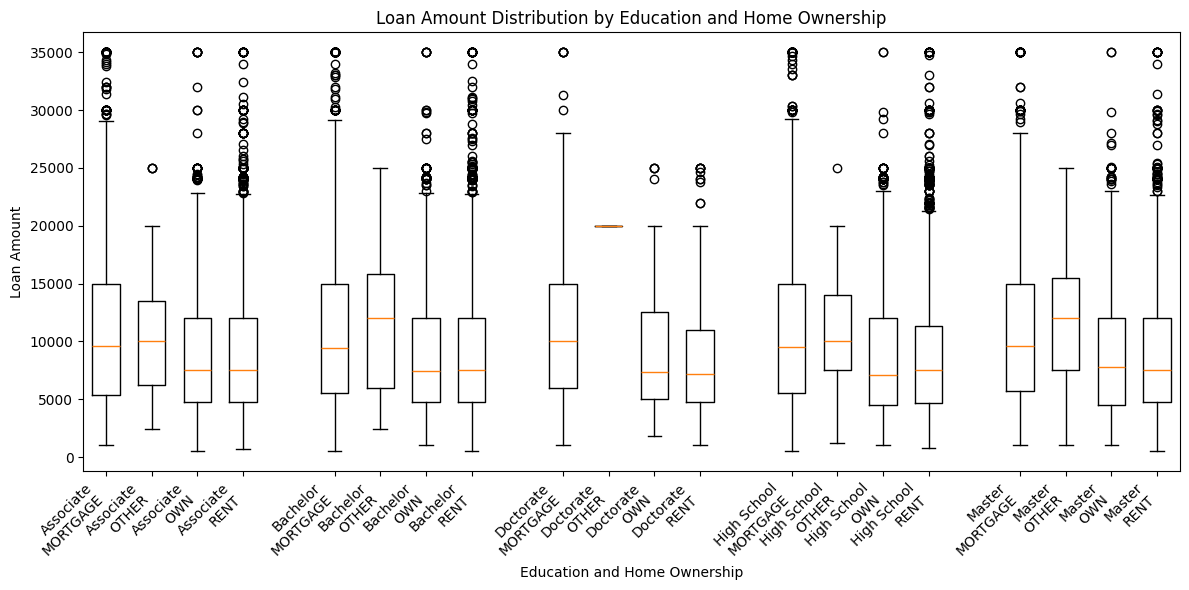

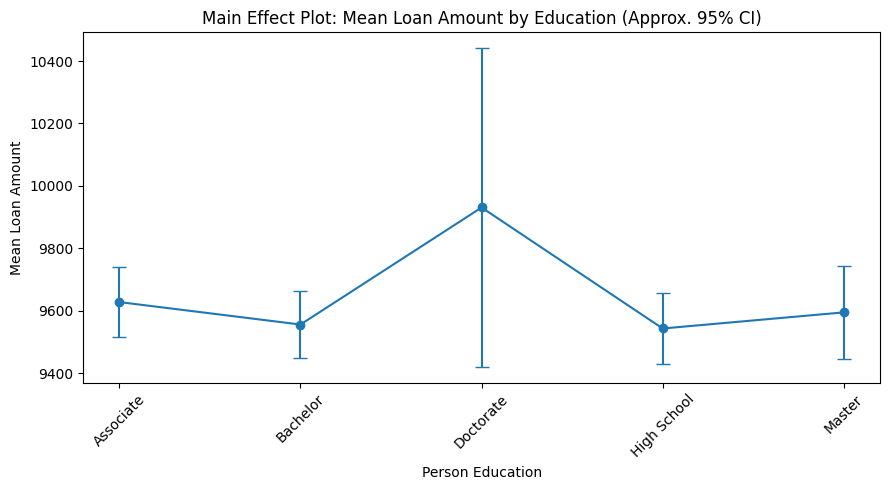

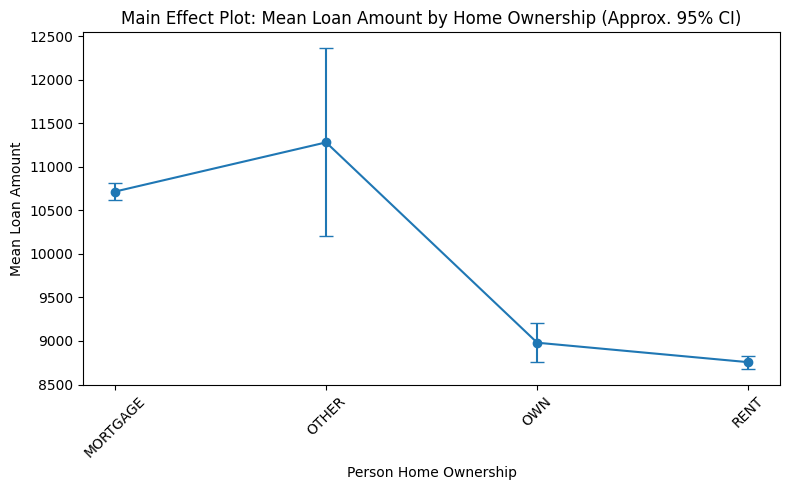

In [11]:
interaction_means = (
    data.groupby([factor_a, factor_b], observed=False)[dv]
    .mean()
    .reset_index()
)

pivot_interaction = interaction_means.pivot(
    index=factor_a,
    columns=factor_b,
    values=dv
)

plt.figure(figsize=(10, 6))
for col in pivot_interaction.columns:
    plt.plot(
        pivot_interaction.index.astype(str),
        pivot_interaction[col],
        marker="o",
        label=str(col)
    )

plt.title("Interaction Plot: Education vs Home Ownership on Loan Amount")
plt.xlabel("Person Education")
plt.ylabel("Mean Loan Amount")
plt.legend(title="Home Ownership")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 9B) Boxplot by both factors using matplotlib only
education_levels = list(data[factor_a].cat.categories)
home_levels = list(data[factor_b].cat.categories)

fig, ax = plt.subplots(figsize=(12, 6))

positions = []
box_data = []
labels = []
pos = 1
gap_between_education_groups = 1

for edu in education_levels:
    for home in home_levels:
        subset = data[(data[factor_a] == edu) & (data[factor_b] == home)][dv].dropna()
        if len(subset) > 0:
            box_data.append(subset.values)
            positions.append(pos)
            labels.append(f"{edu}\n{home}")
        pos += 1
    pos += gap_between_education_groups

ax.boxplot(box_data, positions=positions, widths=0.6)
ax.set_title("Loan Amount Distribution by Education and Home Ownership")
ax.set_xlabel("Education and Home Ownership")
ax.set_ylabel("Loan Amount")
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=45, ha="right")
plt.tight_layout()
plt.show()


# 9C) Main effect plot for education
mean_a = data.groupby(factor_a, observed=False)[dv].mean()
se_a = data.groupby(factor_a, observed=False)[dv].sem()

plt.figure(figsize=(9, 5))
plt.errorbar(
    x=range(len(mean_a.index)),
    y=mean_a.values,
    yerr=1.96 * se_a.values,
    fmt="o-",
    capsize=5
)
plt.xticks(range(len(mean_a.index)), mean_a.index.astype(str), rotation=45)
plt.title("Main Effect Plot: Mean Loan Amount by Education (Approx. 95% CI)")
plt.xlabel("Person Education")
plt.ylabel("Mean Loan Amount")
plt.tight_layout()
plt.show()


# 9D) Main effect plot for home ownership
mean_b = data.groupby(factor_b, observed=False)[dv].mean()
se_b = data.groupby(factor_b, observed=False)[dv].sem()

plt.figure(figsize=(8, 5))
plt.errorbar(
    x=range(len(mean_b.index)),
    y=mean_b.values,
    yerr=1.96 * se_b.values,
    fmt="o-",
    capsize=5
)
plt.xticks(range(len(mean_b.index)), mean_b.index.astype(str), rotation=45)
plt.title("Main Effect Plot: Mean Loan Amount by Home Ownership (Approx. 95% CI)")
plt.xlabel("Person Home Ownership")
plt.ylabel("Mean Loan Amount")
plt.tight_layout()
plt.show()


## Interpretation Guide

This section provides guidance on how to interpret the results:

- If the interaction is not significant:
  - Main effects can be interpreted independently

- If a main effect is significant:
  - Loan amounts differ across levels of that variable
  - Post-hoc results should be used to identify specific group differences

Effect size (η²) is also considered:
- ~0.01 = small effect
- ~0.06 = medium effect
- ~0.14 = large effect

In [12]:
print("\n" + "=" * 70)
print("INTERPRETATION HELPER")
print("=" * 70)

if not sig_interaction:
    print(
        f"\nThere is no statistically significant interaction between {factor_a} and {factor_b}."
    )
    print(
        "This means you can interpret the main effects independently."
    )
else:
    print(
        f"\nThere is a statistically significant interaction between {factor_a} and {factor_b}."
    )
    print(
        "Interpret the interaction first before interpreting the main effects."
    )

if sig_a:
    print(f"\nSignificant main effect: {factor_a}")
    print(
        f"Interpretation: mean {dv} differs across levels of {factor_a}, "
        f"averaging over {factor_b}."
    )
    print("Use the Tukey output and the mean table to identify which groups differ.")
else:
    print(f"\nNo significant main effect for {factor_a}.")

if sig_b:
    print(f"\nSignificant main effect: {factor_b}")
    print(
        f"Interpretation: mean {dv} differs across levels of {factor_b}, "
        f"averaging over {factor_a}."
    )
    print("Use the Tukey output and the mean table to identify which groups differ.")
else:
    print(f"\nNo significant main effect for {factor_b}.")

print("\nEffect size guideline for eta squared:")
print("~0.01 = small, ~0.06 = medium, ~0.14 = large")

print("\nDone.")


INTERPRETATION HELPER

There is no statistically significant interaction between person_education and person_home_ownership.
This means you can interpret the main effects independently.

No significant main effect for person_education.

Significant main effect: person_home_ownership
Interpretation: mean loan_amount differs across levels of person_home_ownership, averaging over person_education.
Use the Tukey output and the mean table to identify which groups differ.

Effect size guideline for eta squared:
~0.01 = small, ~0.06 = medium, ~0.14 = large

Done.


## Plain English Summary

A final summary is automatically generated to describe the results in clear, non-technical language.

This includes:
- Whether interaction effects are present
- Which main effects are significant
- Direction of differences between groups

This section is useful for communicating results to non-technical audiences.

In [13]:
def interpret_p(p):
    if p < 0.001:
        return "p < .001"
    elif p < 0.01:
        return "p < .01"
    elif p < 0.05:
        return "p < .05"
    else:
        return f"p = {p:.3f}"


print("\n" + "=" * 70)
print("PLAIN ENGLISH RESULTS")
print("=" * 70)

# Extract stats safely
def get_effect_stats(effect_name):
    if effect_name in anova_table.index:
        row = anova_table.loc[effect_name]
        return {
            "F": row["F"],
            "p": row["PR(>F)"],
            "eta": row["eta_sq"]
        }
    return None

a_name = f"C({factor_a})"
b_name = f"C({factor_b})"
int_name = f"C({factor_a}):C({factor_b})"

a_stats = get_effect_stats(a_name)
b_stats = get_effect_stats(b_name)
int_stats = get_effect_stats(int_name)

# Build paragraph
paragraph = []

paragraph.append(
    f"A two-way ANOVA was conducted to examine the effects of {factor_a.replace('_',' ')} "
    f"and {factor_b.replace('_',' ')} on {dv.replace('_',' ')}."
)

# Interaction
if int_stats:
    p = int_stats["p"]
    paragraph.append(
        f"There was {'a statistically significant' if p < 0.05 else 'no statistically significant'} "
        f"interaction between {factor_a.replace('_',' ')} and {factor_b.replace('_',' ')} "
        f"(F = {int_stats['F']:.2f}, {interpret_p(p)}, η² = {int_stats['eta']:.3f})."
    )

# Main effect A
if a_stats:
    p = a_stats["p"]
    paragraph.append(
        f"There was {'a statistically significant' if p < 0.05 else 'no statistically significant'} "
        f"main effect of {factor_a.replace('_',' ')} "
        f"(F = {a_stats['F']:.2f}, {interpret_p(p)}, η² = {a_stats['eta']:.3f})."
    )

# Main effect B
if b_stats:
    p = b_stats["p"]
    paragraph.append(
        f"There was {'a statistically significant' if p < 0.05 else 'no statistically significant'} "
        f"main effect of {factor_b.replace('_',' ')} "
        f"(F = {b_stats['F']:.2f}, {interpret_p(p)}, η² = {b_stats['eta']:.3f})."
    )

# Interpretation logic
if int_stats and int_stats["p"] >= 0.05:
    paragraph.append(
        "Because the interaction was not significant, the main effects can be interpreted independently."
    )

if a_stats and a_stats["p"] < 0.05:
    top_group = means_a.idxmax()
    bottom_group = means_a.idxmin()
    paragraph.append(
        f"On average, individuals in the {top_group} group had the highest loan amounts, "
        f"while those in the {bottom_group} group had the lowest."
    )

if b_stats and b_stats["p"] < 0.05:
    top_group = means_b.idxmax()
    bottom_group = means_b.idxmin()
    paragraph.append(
        f"For {factor_b.replace('_',' ')}, the highest mean loan amount was observed in the {top_group} group, "
        f"and the lowest in the {bottom_group} group."
    )

# Print nicely
print("\n".join(paragraph))


PLAIN ENGLISH RESULTS
A two-way ANOVA was conducted to examine the effects of person education and person home ownership on loan amount.
There was no statistically significant interaction between person education and person home ownership (F = 1.08, p = 0.370, η² = 0.000).
There was no statistically significant main effect of person education (F = 0.58, p = 0.678, η² = 0.000).
There was a statistically significant main effect of person home ownership (F = 352.07, p < .001, η² = 0.023).
Because the interaction was not significant, the main effects can be interpreted independently.
For person home ownership, the highest mean loan amount was observed in the OTHER group, and the lowest in the RENT group.
